# 🔥 Wildfire Map
This notebook loads fire data from the NASA FIRMS API, cleans it, 
and builds an interactive map with choropleth, marker, and heatmap layers.

In [79]:

import requests
import time
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta
import mapclassify
import numpy as np
from folium.plugins import MarkerCluster, HeatMap




Here you download the Wildfire data from the last seven days from the NASA FIRMS API
Get your API-keay here: https://firms.modaps.eosdis.nasa.gov/api/map_key/

In [86]:

#Create a list of the last 7 days in the format YYYY-MM-DD to always have the most recent data when running the notebook
dates = [(datetime.now() - timedelta(days=i)).strftime("%Y-%m-%d") for i in range(7)]

#Get your API key from the NASA FIRMS website and set the base URL

API_KEY= "945978c7c7120107b9bfdfdb322c8ce6" #fill in your perosnal API key heree
base_url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{key}/VIIRS_SNPP_NRT/world/1/"

#create an empty list to store the dataframes for each day
all_data = []

#loop through the dates and make a request for each day, then append it to the all_data list
for d in dates:
    print(f"Load data {d}...")
    response = requests.get(base_url + d)
    response.raise_for_status()
    day_df = pd.read_csv(StringIO(response.text))
    all_data.append(day_df)

#concatenate the seperate data franmes into one
wildfire_live_df = pd.concat(all_data, ignore_index=True)

Load data 2026-05-22...
Load data 2026-05-21...
Load data 2026-05-20...
Load data 2026-05-19...
Load data 2026-05-18...
Load data 2026-05-17...
Load data 2026-05-16...


In this section we clean and prepare our geodata for the later analysis
Get the geoboundaies here : https://www.geoboundaries.org/globalDownloads.html

In [81]:

#creat a geodataframe and set the refernce system to wgs84, because the NASA it is also the system used by the NASA
wildfire_live_gdf = gpd.GeoDataFrame(wildfire_live_df, 
    geometry=gpd.points_from_xy(wildfire_live_df.longitude, wildfire_live_df.latitude))
wildfire_live_gdf= wildfire_live_gdf.set_crs(epsg=4326)

#filter the data to only include normal or high confidence and high firepower
wildfire_live_confidence_gdf =  wildfire_live_gdf[
    ((wildfire_live_gdf['confidence'] == 'n') | 
     (wildfire_live_gdf['confidence'] == 'h'))
    & (wildfire_live_gdf['frp'] >= 5)]

#Reproject to epsg:6933 to calculate the area of each country as exact as possible in knm^2 
countries__reprojected_gdf= gpd.read_file("../data/geoBoundariesCGAZ_ADM0").to_crs(epsg=6933)
#Divide through 10**6 to get from m^2 to km^2
countries__reprojected_gdf["area_km2"]= countries__reprojected_gdf.geometry.area/10**6
#Simplify the geometry to have a smaller dataset for smoother use of the folium maps
countries__reprojected_gdf["geometry"]= countries__reprojected_gdf.geometry.simplify(10000)

#change the crs back to wgs84 because the NASA Dsta geometry is also like this
countries_wgs84_gdf= countries__reprojected_gdf.to_crs(epsg=4326)



/opt/anaconda3/envs/sds-env/lib/python3.14/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)


In this section we create a choropleth map as the first layer of our map. It displays the wildfires that have occured in the last seven days per country per 10'000km^2

In [82]:


# Spatial assignment: Using a point-in-polygon join, we assign each reported fire location to its respective country so that we can aggregate the data at the country level
fires_inside_country_gdf = gpd.sjoin(wildfire_live_confidence_gdf, countries_wgs84_gdf, 
                                  how="right", predicate="within")

fires_per_country_gdf = fires_inside_country_gdf.groupby("shapeName")["longitude"].count().reset_index(name="fire_count")

#merge the fire count per country with the coordinates of the country
fires_per_country_gdf = pd.merge(fires_per_country_gdf, countries_wgs84_gdf, left_on="shapeName", right_on="shapeName")

fires_per_country_gdf = gpd.GeoDataFrame(fires_per_country_gdf, geometry="geometry")


#Data normalisation, we devide the fires by the area of the country to get the realative density of wildfire/10'000km^2
fires_per_country_gdf["fire_density"] = (fires_per_country_gdf["fire_count"] / fires_per_country_gdf["area_km2"]) * 10000

# Create Folium Choropleth map
wildfire_map = folium.Map(location=[20, 0], zoom_start=5, tiles="CartoDB dark_matter")
# Classify the fire density into 5 classes using the Natural breaks classifier
classifier = mapclassify.JenksCaspall(fires_per_country_gdf["fire_density"], k=5)
boundaries = [fires_per_country_gdf["fire_density"].min()] + list(classifier.bins)
# Add the choropleth layer, choose the shapeName and the newly created fire density layer as columns
folium.Choropleth(
    geo_data=fires_per_country_gdf,
    name="Fire_density",
    data=fires_per_country_gdf,
    columns=["shapeName", "fire_density"],
    key_on="feature.properties.shapeName",
    threshold_scale=boundaries,
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Fire Density (per 10,000 km²)"
).add_to(wildfire_map)





In this section we create a marker layer with the most recent wildfires from yesteray

In [83]:

# Convert the dates to datetime and sort them
wildfire_live_confidence_gdf["acq_date"] = pd.to_datetime(wildfire_live_confidence_gdf["acq_date"])
#get all unique dates to be able to filter the data for every single day
unique_dates = sorted(wildfire_live_confidence_gdf['acq_date'].unique(), reverse=True)
# unique_dates[0] would be today
# unique_dates[1] is yesterday
previouse_day = unique_dates[1]
# For this layer we only want the most recent wildfires, so we filter the geodataframe to only include fires from the most recent date in the dataset
fires_today = wildfire_live_confidence_gdf[wildfire_live_confidence_gdf['acq_date'] == previouse_day]
# Create an empty MarkerCluster group and add it to the map
marker_cluster = MarkerCluster(name="fires").add_to(wildfire_map)
# Iterate manually through the GeoDataFrame to ensure tooltips survive clustering
for idx, row in fires_today.iterrows():  
    # Extract coordinates
    lat = row.geometry.y
    lon = row.geometry.x
    # Filter for high and normal confidence to be able to assign different opacities
    if row['confidence'] == 'h':
        marker_opacity = 1.0
    else:
        marker_opacity = 0.4
    # Format the tooltip text explicitly
    tooltip_text = f"Firepower: {row['frp']:.1f}", f"acq_date: {row['acq_date']}"
    # Create the individual marker and add it to the cluster (NOT directly to the map)
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="red", icon="fire", prefix="fa"),
        tooltip=tooltip_text,
        legend="Fire Location",
        opacity=marker_opacity,
    ).add_to(marker_cluster)
    
#To have a legend we need to write a html for this layer
legend_html = '''
<div style="
     position: fixed; 
     font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
     border: 2px solid #ccc;
     border-radius: 6px;
     padding: 12px;
     font-size:14px;
     
     bottom: 50px; left: 50px; width: 200px; height: 100px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.8;">
     &nbsp; <b>Wildfire Confidence</b> <br>
     &nbsp; High Confidence fire &nbsp; <i class="fa fa-fire" style="color:red; opacity: 1"></i><br>
     &nbsp; Low Confidence fire &nbsp; <i class="fa fa-fire" style="color:red; opacity: 0.4";></i><br>
</div>
'''
# Add the legend to the map
wildfire_map.get_root().html.add_child(folium.Element(legend_html))



In this section we create the heatmap layer ot show the change of the wildfires over the last 7 days

In [ ]:


#create two empty lists for the dates and the Indices
Date_List=[]
Index_List=[]

#sort the wildfire dateset by date
wildfire_live_confidence_gdf = wildfire_live_confidence_gdf.sort_values("acq_date")

# Group the dataset by acquisition date to generate daily fire location snapshots.
# For each day, the date is formatted as a string (for the timeline index) and the 
# corresponding coordinates are extracted as a nested list 
# This structure is required for the Heatmapwithtime plugin
for date, group in wildfire_live_confidence_gdf.groupby("acq_date"):
    Date_List.append(date.strftime("%Y-%m-%d"))
    Index_List.append(group[["latitude", "longitude"]].values.tolist())
    
# Create a heatmap layer for each date and add it to the map
HeatMap_layer = folium.plugins.HeatMapWithTime(
    Index_List, 
    index=Date_List, 
    auto_play=False,                                           
    max_opacity=0.3,
    name= "Wildfire Time Series")


HeatMap_layer.add_to(wildfire_map)

#add a Layer Control to navigate between the different layers
folium.LayerControl().add_to(wildfire_map)

#save the wildfire map
wildfire_map.save("../outputs/global_wildfire_map.html")

In the following cell we do some basic spatial analysis of the data

The country with the highest wildfire density is:
Country:              Honduras
Fire count:      1280
Area (km²):      112049.19
Calculated density: 114.24

The country with the most wildfires is:
Land:              Russia
Anzahl Feuer:      11132
Fläche (km²):      16930380.12
Claculatet density: 6.58



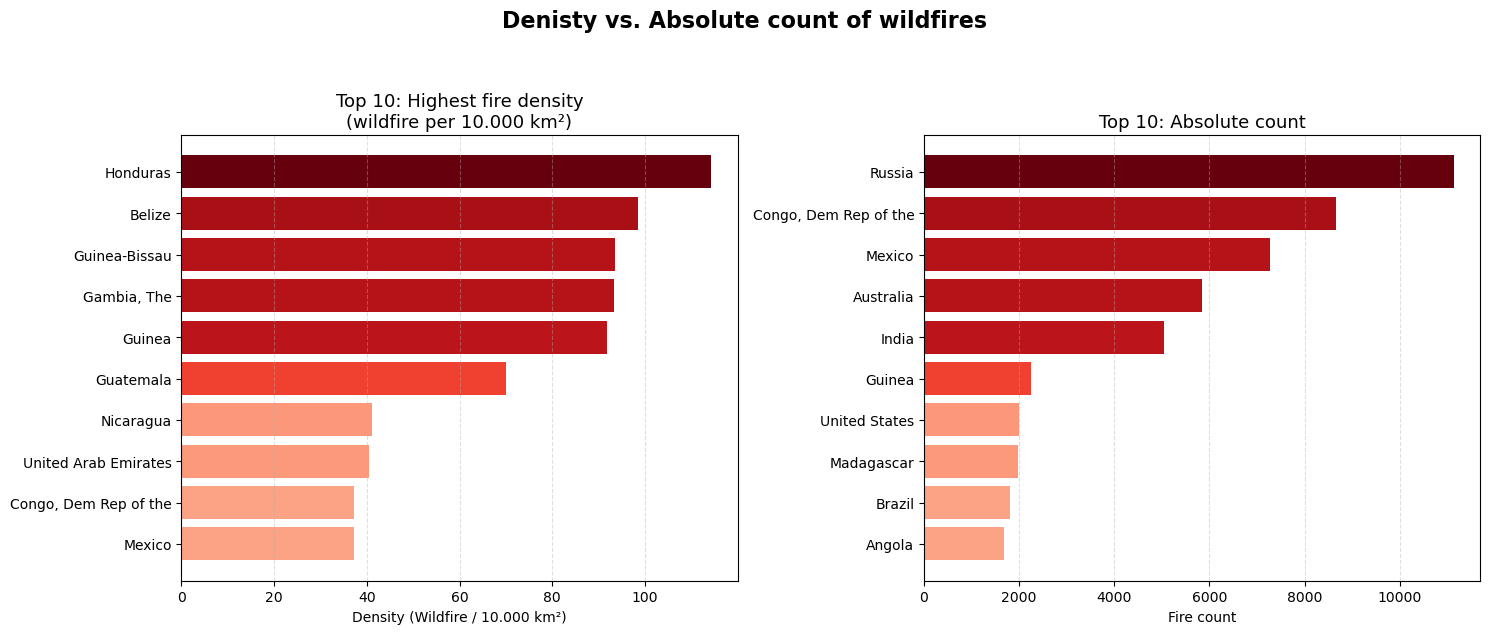

In [85]:
# Statistical analysis & dealing with outliers
large_countries = fires_per_country_gdf[fires_per_country_gdf["area_km2"] > 1000]
max_row = large_countries.loc[large_countries["fire_density"].idxmax()]
Absolut_max_row = fires_per_country_gdf.loc[fires_per_country_gdf["fire_count"].idxmax()]

print("The country with the highest wildfire density is:")
print(f"Country:              {max_row['shapeName']}")
print(f"Fire count:      {max_row['fire_count']}")
print(f"Area (km²):      {max_row['area_km2']:.2f}")
print(f"Calculated density: {max_row['fire_density']:.2f}")

print("\nThe country with the most wildfires is:")
print(f"Land:              {Absolut_max_row['shapeName']}")
print(f"Anzahl Feuer:      {Absolut_max_row['fire_count']}")
print(f"Fläche (km²):      {Absolut_max_row['area_km2']:.2f}")
print(f"Claculatet density: {Absolut_max_row['fire_density']:.2f}\n")

#Data pereparition for plotting

#Top 10 countries sorted by density (without outliers < 1000 km²)  
top_density = large_countries.sort_values(by="fire_density", ascending=False).head(10).iloc[::-1]

# Top 10 countries absolut values
top_absolute = fires_per_country_gdf.sort_values(by="fire_count", ascending=False).head(10).iloc[::-1]


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left plot top 10 densities
colors_density = plt.cm.Reds(top_density["fire_density"] / top_density["fire_density"].max())
axes[0].barh(top_density["shapeName"], top_density["fire_density"], color=colors_density)
axes[0].set_title("Top 10: Highest fire density\n(wildfire per 10.000 km²)", fontsize=13)
axes[0].set_xlabel("Density (Wildfire / 10.000 km²)")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# Right plot top 10 absolute values
axes[1].barh(top_absolute["shapeName"], top_absolute["fire_count"], color=colors_density,)
axes[1].set_title("Top 10: Absolute count", fontsize=13)
axes[1].set_xlabel("Fire count")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)


plt.suptitle("Denisty vs. Absolute count of wildfires", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()
